<a href="https://www.kaggle.com/code/sonawanelalitsunil/global-e-commerce-sales-trends-eda-ml-99-64?scriptVersionId=265802601" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/e-commerce-sales/Ecommerce_Sales_Data_2024_2025.csv


## Title: Global E-Commerce Sales Trends

## Description:
This project explores global e-commerce sales data to uncover insights into customer purchasing behavior, product performance, and sales trends across various categories and time periods. By analyzing key metrics such as total revenue, quantity sold, payment methods, and customer ratings, the study aims to identify factors driving online sales growth. Visualizations highlight seasonal sales patterns, popular product categories, and regional performance variations. The analysis further applies machine learning models to predict future sales, helping businesses optimize pricing strategies, inventory management, and marketing decisions.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/e-commerce-sales/Ecommerce_Sales_Data_2024_2025.csv")

In [3]:
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


In [4]:
df.tail()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
4995,14996,2024-06-25,Nishith Kulkarni,East,Kolkata,Books,Fiction,Fiction Veritatis,3,60671,0,182013.0,11853.15,Debit Card
4996,14997,2024-12-22,Aaina Chander,North,Jaipur,Toys,Doll,Doll Nulla,5,70048,0,350240.0,31237.23,Credit Card
4997,14998,2025-04-15,Dhanush Gara,South,Bangalore,Beauty,Lipstick,Lipstick Eaque,1,42162,15,35837.7,7827.50,Debit Card
4998,14999,2024-07-08,Divyansh Malhotra,East,Kolkata,Electronics,Smartwatch,Smartwatch Adipisci,4,13568,10,48844.8,6603.86,Credit Card
4999,15000,2024-02-04,Aarush Walla,West,Goa,Clothing,Kids Wear,Kids Wear Repellat,1,76762,10,69085.8,5785.85,Net Banking


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   int64  
 1   Order Date     5000 non-null   object 
 2   Customer Name  5000 non-null   object 
 3   Region         5000 non-null   object 
 4   City           5000 non-null   object 
 5   Category       5000 non-null   object 
 6   Sub-Category   5000 non-null   object 
 7   Product Name   5000 non-null   object 
 8   Quantity       5000 non-null   int64  
 9   Unit Price     5000 non-null   int64  
 10  Discount       5000 non-null   int64  
 11  Sales          5000 non-null   float64
 12  Profit         5000 non-null   float64
 13  Payment Mode   5000 non-null   object 
dtypes: float64(2), int64(4), object(8)
memory usage: 547.0+ KB


In [6]:
df.describe()

,Order ID,Quantity,Unit Price,Discount,Sales,Profit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2.992600,39760.904600,10.051000,106733.204870,15941.746982
std,1443.520003,1.413133,22831.783946,7.084662,85108.208202,14897.684916
min,10001.000000,1.000000,222.000000,0.000000,264.100000,19.120000
25%,11250.750000,2.000000,20312.250000,5.000000,39766.537500,4892.295000
50%,12500.500000,3.000000,39459.500000,10.000000,83080.325000,11108.525000
75%,13750.250000,4.000000,59721.750000,15.000000,156968.587500,22467.987500
max,15000.000000,5.000000,79998.000000,20.000000,398485.000000,89688.440000


In [7]:
df.isnull().sum()

Order ID         0
Order Date       0
Customer Name    0
Region           0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Unit Price       0
Discount         0
Sales            0
Profit           0
Payment Mode     0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.nunique()

Order ID         5000
Order Date        730
Customer Name    4844
Region              4
City               20
Category           10
Sub-Category       50
Product Name     3835
Quantity            5
Unit Price       4841
Discount            5
Sales            4978
Profit           4996
Payment Mode        5
dtype: int64

In [10]:
df.describe().loc[['min','max','mean']]

,Order ID,Quantity,Unit Price,Discount,Sales,Profit
min,10001.0,1.0000,222.0000,0.000,264.10000,19.120000
max,15000.0,5.0000,79998.0000,20.000,398485.00000,89688.440000
mean,12500.5,2.9926,39760.9046,10.051,106733.20487,15941.746982


In [11]:
df.dtypes

Order ID           int64
Order Date        object
Customer Name     object
Region            object
City              object
Category          object
Sub-Category      object
Product Name      object
Quantity           int64
Unit Price         int64
Discount           int64
Sales            float64
Profit           float64
Payment Mode      object
dtype: object

In [12]:
df.shape

(5000, 14)

In [13]:
df.columns

Index(['Order ID', 'Order Date', 'Customer Name', 'Region', 'City', 'Category',
       'Sub-Category', 'Product Name', 'Quantity', 'Unit Price', 'Discount',
       'Sales', 'Profit', 'Payment Mode'],
      dtype='object')

## Data visualizations

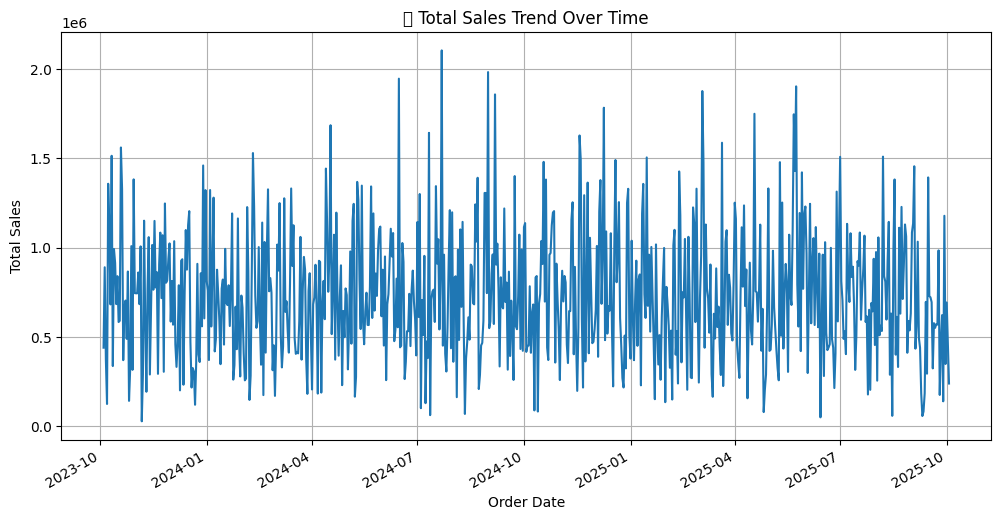

In [14]:
# 🧹 Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# 🧭 1️⃣ Sales trend over time
plt.figure(figsize=(12,6))
df.groupby('Order Date')['Sales'].sum().plot()
plt.title('📈 Total Sales Trend Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

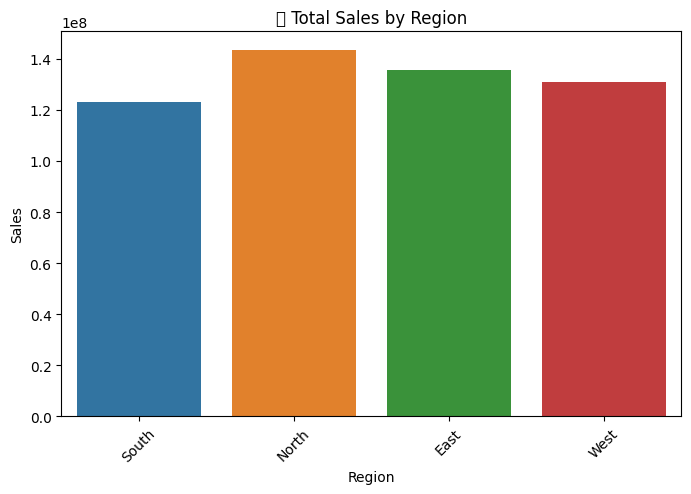

In [15]:
# 🏙️ 2️⃣ Sales by Region
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Sales', data=df, estimator='sum', ci=None)
plt.title('💰 Total Sales by Region')
plt.xticks(rotation=45)
plt.show()

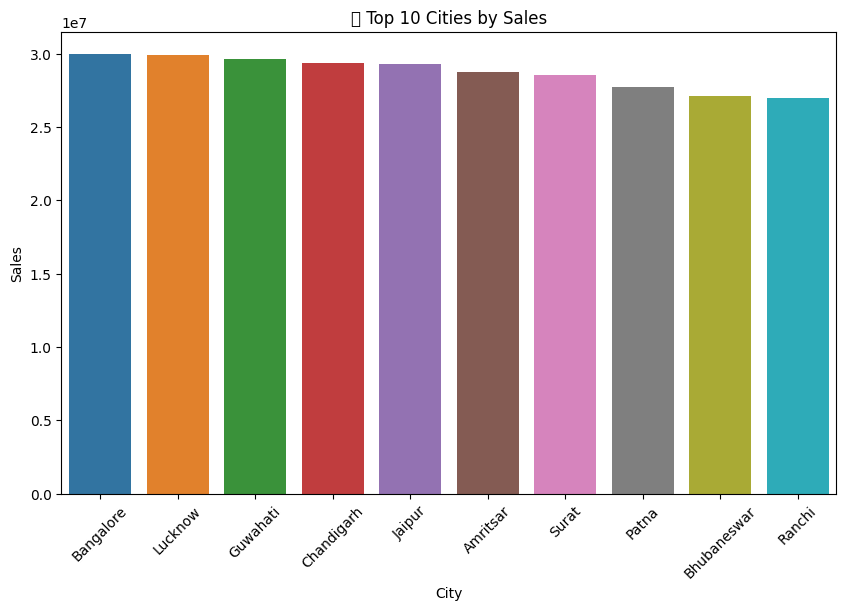

In [16]:
# 🏠 3️⃣ Top 10 Cities by Sales
top_cities = df.groupby('City')['Sales'].sum().nlargest(10).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(x='City', y='Sales', data=top_cities)
plt.title('🏙️ Top 10 Cities by Sales')
plt.xticks(rotation=45)
plt.show()

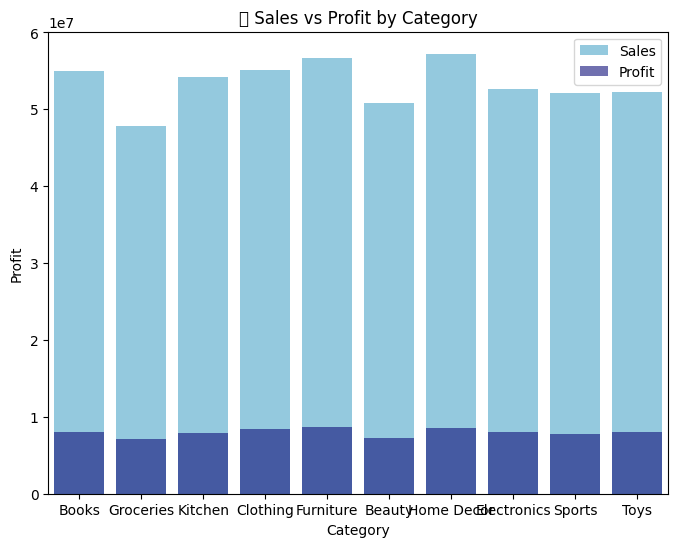

In [17]:
# 🛍️ 4️⃣ Sales and Profit by Category
plt.figure(figsize=(8,6))
sns.barplot(x='Category', y='Sales', data=df, estimator='sum', ci=None, color='skyblue', label='Sales')
sns.barplot(x='Category', y='Profit', data=df, estimator='sum', ci=None, color='darkblue', alpha=0.6, label='Profit')
plt.title('📦 Sales vs Profit by Category')
plt.legend()
plt.show()

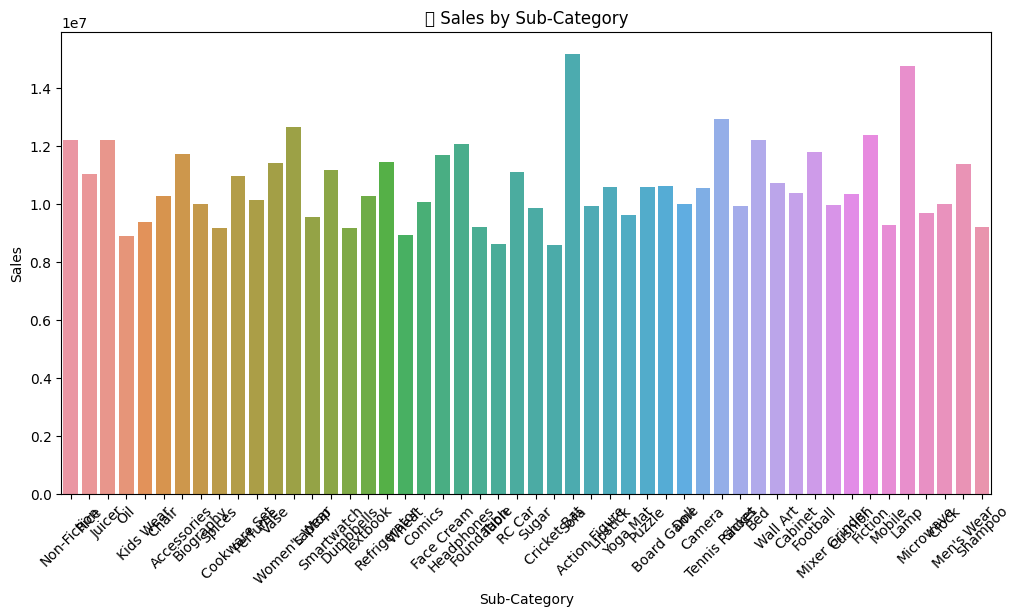

In [18]:
# 📚 5️⃣ Sub-Category wise Sales Distribution
plt.figure(figsize=(12,6))
sns.barplot(x='Sub-Category', y='Sales', data=df, estimator='sum', ci=None)
plt.title('🧩 Sales by Sub-Category')
plt.xticks(rotation=45)
plt.show()

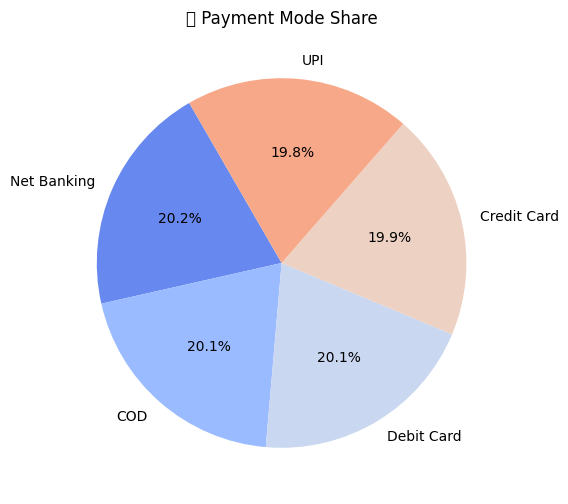

In [19]:
# 💳 6️⃣ Payment Mode Distribution
plt.figure(figsize=(6,6))
df['Payment Mode'].value_counts().plot.pie(autopct='%1.1f%%', startangle=120, colors=sns.color_palette('coolwarm'))
plt.title('💳 Payment Mode Share')
plt.ylabel('')
plt.show()

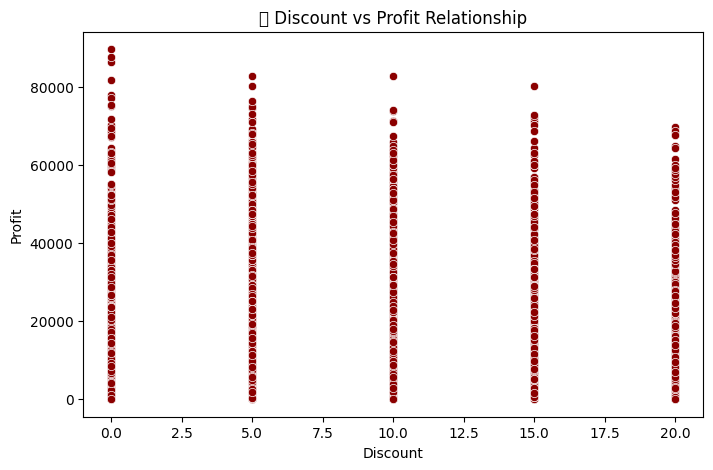

In [20]:
# 📈 7️⃣ Relationship between Discount and Profit
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df, color='darkred')
plt.title('📉 Discount vs Profit Relationship')
plt.show()


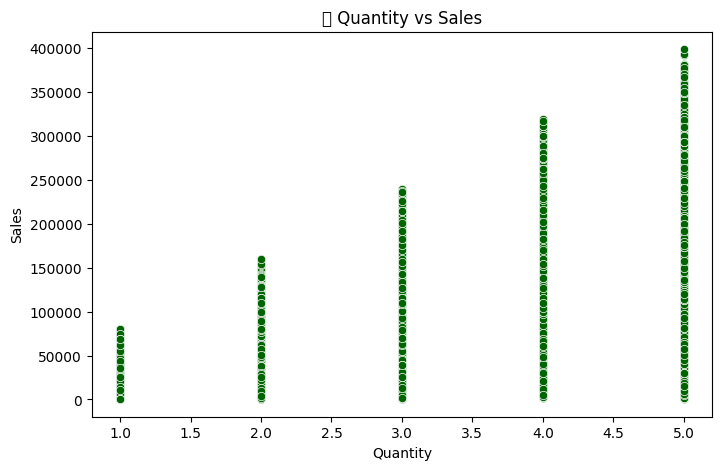

In [21]:
# 💰 8️⃣ Quantity vs Sales
plt.figure(figsize=(8,5))
sns.scatterplot(x='Quantity', y='Sales', data=df, color='darkgreen')
plt.title('📊 Quantity vs Sales')
plt.show()

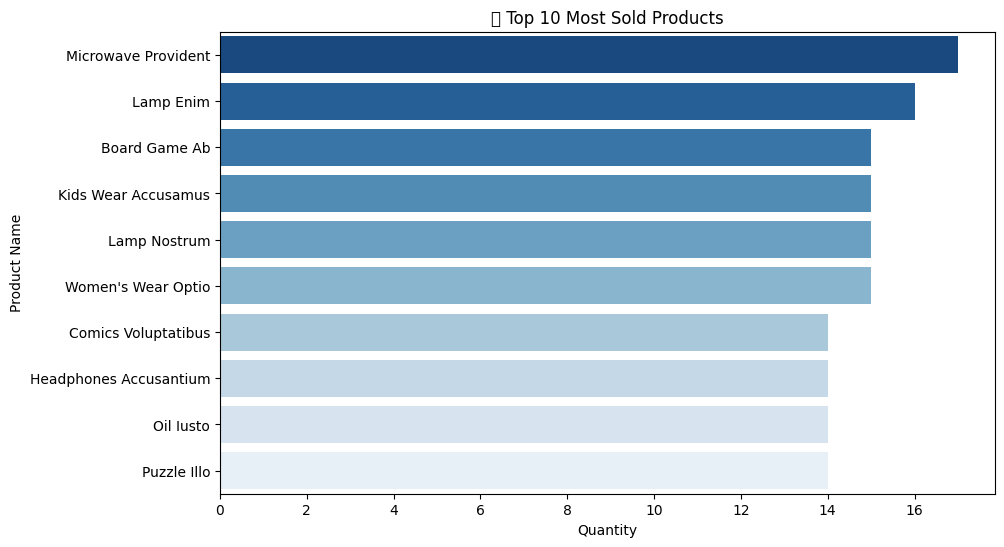

In [22]:
# 🏆 9️⃣ Top 10 Most Sold Products
top_products = df.groupby('Product Name')['Quantity'].sum().nlargest(10).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(x='Quantity', y='Product Name', data=top_products, palette='Blues_r')
plt.title('🏆 Top 10 Most Sold Products')
plt.show()

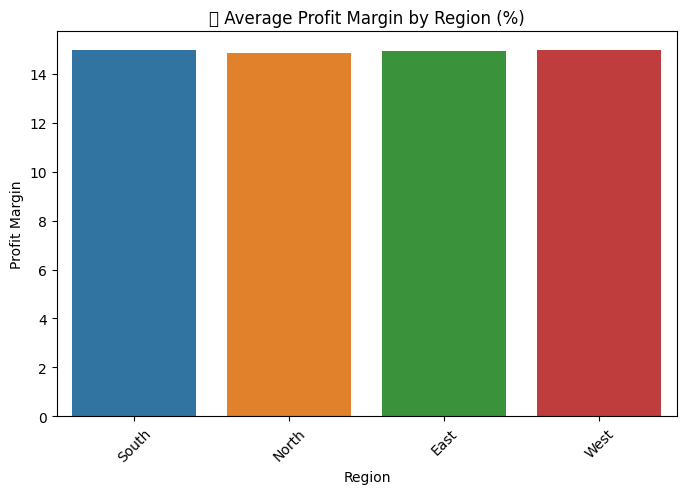

In [23]:
# 💹 🔟 Profit Margin by Region
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Profit Margin', data=df, estimator='mean', ci=None)
plt.title('💹 Average Profit Margin by Region (%)')
plt.xticks(rotation=45)
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import AdaBoostRegressor

In [25]:
df = df.dropna()
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Drop columns that are identifiers or not predictive
df = df.drop(['Order ID', 'Order Date', 'Customer Name'], axis=1)

# Separate target and features
target = 'Profit'
X = df.drop(columns=[target])
y = df[target]


In [26]:
label_enc = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = label_enc.fit_transform(X[col])

# 🧩 Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

In [28]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = r2_score(y_test, preds) * 100  # Convert to percentage
    results[name] = acc

In [29]:
accuracy_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy (%)"])
accuracy_df = accuracy_df.sort_values(by="Accuracy (%)", ascending=False)

print("📈 Model Performance:")
print(accuracy_df)

📈 Model Performance:
               Model  Accuracy (%)
2      Random Forest     99.877586
3  Gradient Boosting     99.822124
1      Decision Tree     99.517295
4           AdaBoost     95.490118
0  Linear Regression     88.781064
5                KNN     65.674778
6                SVR     -2.425620


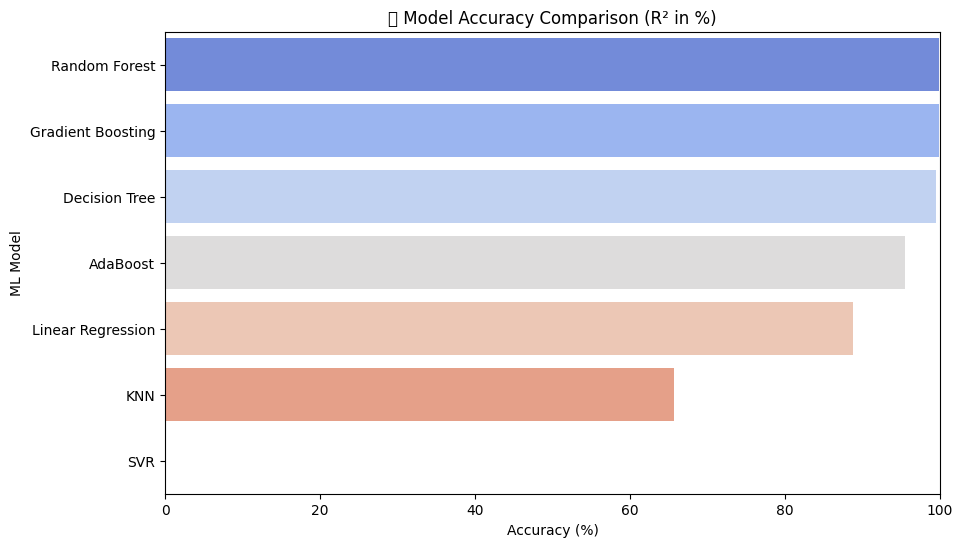

In [30]:
plt.figure(figsize=(10,6))
sns.barplot(x='Accuracy (%)', y='Model', data=accuracy_df, palette='coolwarm')
plt.title('🔍 Model Accuracy Comparison (R² in %)')
plt.xlabel('Accuracy (%)')
plt.ylabel('ML Model')
plt.xlim(0, 100)
plt.show()

## Thank you...pls upvote!!!!